# CR: Lotka-Volterra

  0%|                                                    | 0/17 [00:00<?, ?it/s]

  6%|██▌                                         | 1/17 [00:06<01:36,  6.00s/it]

 12%|█████▏                                      | 2/17 [00:07<00:51,  3.40s/it]

 18%|███████▊                                    | 3/17 [00:08<00:30,  2.19s/it]

 24%|██████████▎                                 | 4/17 [00:08<00:20,  1.59s/it]

...

 82%|███████████████████████████████████▍       | 14/17 [00:17<00:03,  1.05s/it]

 88%|█████████████████████████████████████▉     | 15/17 [00:18<00:02,  1.07s/it]

 94%|████████████████████████████████████████▍  | 16/17 [00:20<00:01,  1.27s/it]

100%|███████████████████████████████████████████| 17/17 [00:21<00:00,  1.32s/it]

100%|███████████████████████████████████████████| 17/17 [00:21<00:00,  1.29s/it]

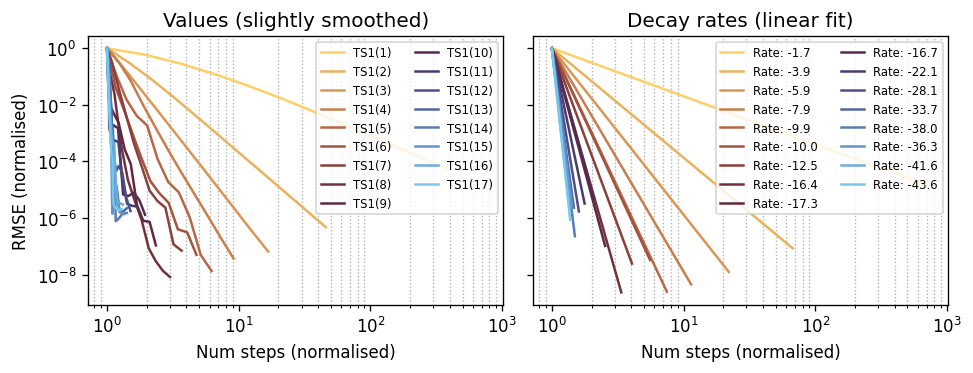

In [1]:
"""Evaluate the convergence rates of the probabilistic solvers."""

import functools
import statistics
import timeit
from collections.abc import Callable

import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate
import tqdm

from probdiffeq import ivpsolve, probdiffeq, taylor

# Fail this notebook on NaN detection (to catch those in the CI)
jax.config.update("jax_debug_nans", True)


def main() -> None:
    """Run the script."""
    # High order solvers need double precision
    jax.config.update("jax_enable_x64", True)

    # Assemble algorithms
    algorithms = {
        r"TS1(1)": solver_probdiffeq(1),
        r"TS1(2)": solver_probdiffeq(2),
        r"TS1(3)": solver_probdiffeq(3),
        r"TS1(4)": solver_probdiffeq(4),
        r"TS1(5)": solver_probdiffeq(5),
        r"TS1(6)": solver_probdiffeq(6),
        r"TS1(7)": solver_probdiffeq(7),
        r"TS1(8)": solver_probdiffeq(8),
        r"TS1(9)": solver_probdiffeq(9),
        r"TS1(10)": solver_probdiffeq(10),
        r"TS1(11)": solver_probdiffeq(11),
        r"TS1(12)": solver_probdiffeq(12),
        r"TS1(13)": solver_probdiffeq(13),
        r"TS1(14)": solver_probdiffeq(14),
        r"TS1(15)": solver_probdiffeq(15),
        r"TS1(16)": solver_probdiffeq(16),
        r"TS1(17)": solver_probdiffeq(17),
    }

    # Set up the benchmark (compute a reference etc.)
    reference = solver_scipy(method="LSODA")(1e-12)
    tolerances = 0.1 ** jnp.arange(2, 8, step=0.5)
    precision_fun = rmse_relative(reference)
    timeit_fun = timer()

    # Compute all work-precision diagrams
    results = {}
    for label, algo in tqdm.tqdm(algorithms.items()):
        param_to_wp = workprec(algo, precision_fun=precision_fun, timeit_fun=timeit_fun)
        results[label] = param_to_wp(tolerances)

    layout = [["values", "trends"]]
    _fig, ax = plt.subplot_mosaic(
        layout,
        figsize=(8, 3),
        constrained_layout=True,
        dpi=120,
        sharex=True,
        sharey=True,
    )
    for i, (keys, values) in enumerate(results.items()):
        cmap = mpl.colormaps["managua"]
        i_clipped = i / len(results.keys())
        color = mpl.colors.to_hex(cmap(i_clipped))

        # Smooth curves
        x, y = smooth(values["work_num_steps"], values["precision"])
        (x_lin, y_lin), (scale, _) = linear_trend(
            values["work_num_steps"], values["precision"]
        )

        # All curves start at (1, 1)
        ax["values"].loglog(x / x.min(), y / y.max(), color=color, label=keys)
        ax["trends"].loglog(
            x_lin / x_lin.min(),
            y_lin / y_lin.max(),
            color=color,
            label=f"Rate: {scale:.1f}",
        )

    ax["values"].set_title("Values (slightly smoothed)")
    ax["trends"].set_title("Decay rates (linear fit)")
    ax["values"].set_ylabel("RMSE (normalised)")

    for a in [ax["values"], ax["trends"]]:
        a.grid(which="minor", linestyle="dotted")
        a.set_xlabel("Num steps (normalised)")
        a.legend(fontsize="x-small", ncols=2)
    plt.show()


def solver_scipy(*, method: str) -> Callable:
    """Construct a solver that wraps SciPy's solution routines."""

    def vf_scipy(_t, y):
        """Lotka--Volterra dynamics."""
        dy1 = 0.5 * y[0] - 0.05 * y[0] * y[1]
        dy2 = -0.5 * y[1] + 0.05 * y[0] * y[1]
        return np.asarray([dy1, dy2])

    u0 = jnp.asarray((20.0, 20.0))
    time_span = np.asarray([0.0, 50.0])

    def param_to_solution(tol):
        solution = scipy.integrate.solve_ivp(
            vf_scipy,
            y0=u0,
            t_span=time_span,
            t_eval=time_span,
            atol=1e-3 * tol,
            rtol=tol,
            method=method,
        )
        return jnp.asarray(solution.y[..., -1])

    return param_to_solution


def rmse_relative(expected: jax.Array, *, nugget=1e-5) -> Callable:
    """Compute the relative RMSE."""
    expected = jnp.asarray(expected)

    def rmse(received):
        received = jnp.asarray(received)
        error_absolute = jnp.abs(expected - received)
        error_relative = error_absolute / jnp.abs(nugget + expected)
        return jnp.linalg.norm(error_relative) / jnp.sqrt(error_relative.size)

    return rmse


def timer():
    """Construct a timing function."""

    def timeit_fun(fun, /):
        return list(timeit.repeat(fun, number=1, repeat=1))

    return timeit_fun


def solver_probdiffeq(num_derivatives: int) -> Callable:
    """Construct a solver that wraps ProbDiffEq's solution routines."""

    @jax.jit
    def vf_probdiffeq(y, /, *, t):  # noqa: ARG001
        """Lotka--Volterra dynamics."""
        dy1 = 0.5 * y[0] - 0.05 * y[0] * y[1]
        dy2 = -0.5 * y[1] + 0.05 * y[0] * y[1]
        return jnp.asarray([dy1, dy2])

    u0 = jnp.asarray((20.0, 20.0))
    t0, t1 = (0.0, 50.0)

    @jax.jit
    def param_to_solution(tol):
        # Do inside the function so we jit the Taylor code
        vf_auto = functools.partial(vf_probdiffeq, t=t0)
        tcoeffs = taylor.odejet_padded_scan(vf_auto, (u0,), num=num_derivatives)

        # Build a solver
        init, ssm = probdiffeq.ssm_taylor(tcoeffs, ssm_fact="dense")
        iwp = probdiffeq.prior_wiener_integrated(ssm=ssm)
        strategy = probdiffeq.strategy_filter(ssm=ssm)
        ts = probdiffeq.constraint_ode_ts1(vf_probdiffeq, ssm=ssm)
        solver = probdiffeq.solver(strategy=strategy, prior=iwp, constraint=ts, ssm=ssm)
        error = probdiffeq.error_residual_std(constraint=ts, prior=iwp, ssm=ssm)

        control = ivpsolve.control_proportional_integral()
        solve = ivpsolve.solve_adaptive_terminal_values(
            solver=solver, error=error, control=control
        )

        # Solve
        dt0 = ivpsolve.dt0(vf_auto, (u0,))
        solution = solve(init, t0=t0, t1=t1, dt0=dt0, atol=1e-2 * tol, rtol=tol)

        # Return the terminal value
        return solution.u.mean[0], solution.num_steps

    return param_to_solution


def workprec(fun, *, precision_fun: Callable, timeit_fun: Callable) -> Callable:
    """Turn a parameter-to-solution function into parameter-to-workprecision."""

    def parameter_list_to_workprecision(list_of_args, /):
        works_num_steps = []
        works_min = []
        works_mean = []
        works_std = []
        precisions = []
        for arg in list_of_args:
            _x, num_steps = fun(arg)

            precision = precision_fun(fun(arg)[0].block_until_ready())
            times = timeit_fun(lambda: fun(arg)[0].block_until_ready())  # noqa: B023

            precisions.append(precision)
            works_num_steps.append(num_steps)
            works_min.append(min(times))
            works_mean.append(statistics.mean(times))
            if len(times) > 1:
                works_std.append(statistics.stdev(times))
        return {
            "work_mean": jnp.asarray(works_mean),
            "work_min": jnp.asarray(works_min),
            "work_num_steps": jnp.asarray(works_num_steps),
            "work_std": jnp.asarray(works_std),
            "precision": jnp.asarray(precisions),
        }

    return parameter_list_to_workprecision


def smooth(x, y, window=2):
    """Smooth a set of data points to improve visualisation."""
    kernel = jnp.ones((window,)) / window
    x = jnp.convolve(x, kernel, mode="valid")
    y = jnp.convolve(y, kernel, mode="valid")
    return x, y


def linear_trend(x, y):
    """Fit a linear curve through the logarithms of x and y."""
    x = jnp.log10(x)
    y = jnp.log10(y)
    scale, bias = jnp.polyfit(x, y, 1)
    return (10 ** (x), 10 ** (scale * x + bias)), (scale, bias)


main()